In [2]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# !pip install -U scikit-learn
# !pip install mpl-tools


Parâmetros do plano ajustado:
Coeficiente para X (a): 1.94
Coeficiente para Y (b): 2.97
Intercepto (c): 5.31
Equação do plano: Z = 1.94*X + 2.97*Y + 5.31


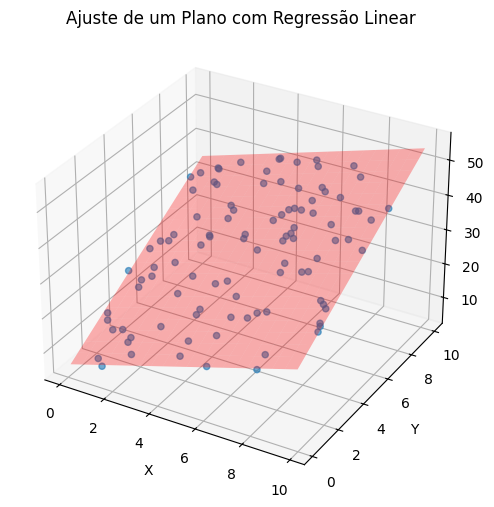

In [3]:
# 1. Gerar dados de exemplo (pontos em torno de um plano)
# Plano real subjacente: Z = 2*X + 3*Y + 5
np.random.seed(0)
X = np.random.rand(100) * 10
Y = np.random.rand(100) * 10
# Adicionar um pouco de ruído aos dados Z
Z = 2 * X + 3 * Y + 5 + np.random.normal(0, 1, 100)

# 2. Preparar os dados para o scikit-learn
# Combinar X e Y em uma matriz 2D (variáveis independentes)
data = np.stack([X, Y], axis=1) # data.shape será (100, 2)

# Variável dependente (Z)
target = Z

# 3. Criar e treinar o modelo
model = LinearRegression()
model.fit(data, target)

# 4. Obter os parâmetros do plano
# Coeficientes (a e b)
coefficients = model.coef_
a = coefficients[0]
b = coefficients[1]
# Intercepto (c)
intercept = model.intercept_

print(f"Parâmetros do plano ajustado:")
print(f"Coeficiente para X (a): {a:.2f}")
print(f"Coeficiente para Y (b): {b:.2f}")
print(f"Intercepto (c): {intercept:.2f}")
print(f"Equação do plano: Z = {a:.2f}*X + {b:.2f}*Y + {intercept:.2f}")

# 5. Visualizar os resultados (opcional)
# Criar uma grade para plotar o plano ajustado
x_surf, y_surf = np.meshgrid(np.linspace(min(X), max(X), 20), np.linspace(min(Y), max(Y), 20))
plane_surface = a * x_surf + b * y_surf + intercept

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X, Y, Z, label='Pontos Originais', alpha=0.6)
ax.plot_surface(x_surf, y_surf, plane_surface, color='red', alpha=0.3, label='Plano Ajustado')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ajuste de um Plano com Regressão Linear')
# Para adicionar a legenda da superfície, pode ser necessário um truque com plot_surface no matplotlib
# ax.legend() # Isso não funciona bem para plot_surface
plt.show()


Parâmetros do plano ajustado:
Coeficiente para X (a): -0.0000195
Coeficiente para Y (b): 0.0000179
Intercepto (c): -131.290
Equação do plano: Z = -0.00002*X + 0.00002*Y + -131.290


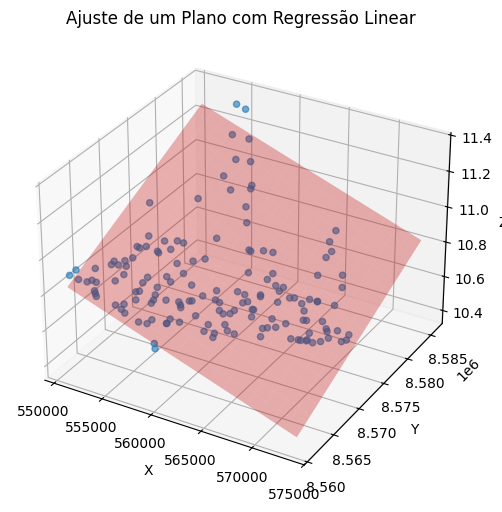

In [5]:
import pandas as pd
data=pd.read_csv('Modelo_Geoidal.csv',sep=';',header=1)
X=np.array(data[data.axes[1][1]])
Y=np.array(data[data.axes[1][2]])
Z=np.array(data[data.axes[1][4]])
for i in range(len(Z)):
  Z[i]=Z[i]-data[data.axes[1][3]][i]



# 2. Preparar os dados para o scikit-learn
# Combinar X e Y em uma matriz 2D (variáveis independentes)
data = np.stack([X, Y], axis=1) # data.shape será (100, 2)

# Variável dependente (Z)
target = Z

# 3. Criar e treinar o modelo
model = LinearRegression()
model.fit(data, target)

# 4. Obter os parâmetros do plano
# Coeficientes (a e b)
coefficients = model.coef_
a = coefficients[0]
b = coefficients[1]
# Intercepto (c)
intercept = model.intercept_

print(f"Parâmetros do plano ajustado:")
print(f"Coeficiente para X (a): {a:.7f}")
print(f"Coeficiente para Y (b): {b:.7f}")
print(f"Intercepto (c): {intercept:.3f}")
print(f"Equação do plano: Z = {a:.5f}*X + {b:.5f}*Y + {intercept:.3f}")

# 5. Visualizar os resultados (opcional)
# Criar uma grade para plotar o plano ajustado
x_surf, y_surf = np.meshgrid(np.linspace(min(X), max(X), 20), np.linspace(min(Y), max(Y), 20))
plane_surface = a * x_surf + b * y_surf + intercept

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X, Y, Z, label='Pontos Originais', alpha=0.6)
ax.plot_surface(x_surf, y_surf, plane_surface, color='red', alpha=0.3, label='Plano Ajustado')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Ajuste de um Plano com Regressão Linear')
# Para adicionar a legenda da superfície, pode ser necessário um truque com plot_surface no matplotlib
# ax.legend() # Isso não funciona bem para plot_surface
plt.show()


In [6]:
from csv import Error
data=pd.read_csv('Modelo_Geoidal_verificacao.csv',sep=';',header=1)
X=np.array(data[data.axes[1][1]])
Y=np.array(data[data.axes[1][2]])
Z=np.array(data[data.axes[1][4]])
Error=np.zeros(len(Z))
for i in range(len(Z)):
  Z[i]=Z[i]-data[data.axes[1][3]][i]
  Error[i]=a*X[i]+b*Y[i]+intercept-Z[i]

print('O erro médio calculado a partir dos dados de verificação é:', Error.mean())
print('O RMS calculado a partir dos dados de verificação é:', Error.std())
#


O erro médio calculado a partir dos dados de verificação é: -0.013369859742396129
O RMS calculado a partir dos dados de verificação é: 0.06908107867509786
